In [1]:
# CELDA 1: Importar librerías
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8')
print("✅ Librerías cargadas")

✅ Librerías cargadas


In [3]:
# =============================================
# CELDA 2: Reconectar a SQL Server y cargar datos
# =============================================
SERVER   = 'GOLDOPC\SQLSERVER2'
DATABASE = 'SuperstoreDB'

engine = create_engine(
    f'mssql+pyodbc://{SERVER}/{DATABASE}'
    f'?driver=ODBC+Driver+17+for+SQL+Server'
    f'&trusted_connection=yes'
)

query = """
    SELECT
        o.OrderID, o.OrderDate, o.ShipMode,
        c.Segment,
        g.Region,
        p.Category, p.SubCategory,
        od.Sales, od.Quantity, od.Discount, od.Profit
    FROM OrderDetails od
    INNER JOIN Orders    o ON od.OrderID   = o.OrderID
    INNER JOIN Customers c ON o.CustomerID = c.CustomerID
    INNER JOIN Geography g ON o.GeoID      = g.GeoID
    INNER JOIN Products  p ON od.ProductID = p.ProductID
"""

df = pd.read_sql(query, engine)
print(f"✅ Datos cargados: {df.shape[0]:,} filas x {df.shape[1]} columnas")

✅ Datos cargados: 9,986 filas x 11 columnas


In [4]:
# =============================================
# CELDA 3: Crear variable objetivo y encodear
# =============================================

# Variable objetivo: 1 = rentable, 0 = pérdida
df['EsRentable'] = (df['Profit'] > 0).astype(int)

print("Distribución de clases:")
print(df['EsRentable'].value_counts())
print(f"\nBalance: {df['EsRentable'].mean()*100:.1f}% transacciones rentables")

# Encodear variables categóricas
le = LabelEncoder()
df['ShipMode_enc']    = le.fit_transform(df['ShipMode'])
df['Segment_enc']     = le.fit_transform(df['Segment'])
df['Region_enc']      = le.fit_transform(df['Region'])
df['Category_enc']    = le.fit_transform(df['Category'])
df['SubCategory_enc'] = le.fit_transform(df['SubCategory'])

# Definir features y objetivo
features = ['Sales', 'Quantity', 'Discount',
            'ShipMode_enc', 'Segment_enc', 'Region_enc',
            'Category_enc', 'SubCategory_enc']

X = df[features]
y = df['EsRentable']

print(f"\n✅ Features listos: {X.shape}")

Distribución de clases:
EsRentable
1    8051
0    1935
Name: count, dtype: int64

Balance: 80.6% transacciones rentables

✅ Features listos: (9986, 8)


In [5]:
# =============================================
# CELDA 4: Dividir datos en entrenamiento y prueba
# =============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% entrenamiento, 20% prueba
    random_state=42,    # semilla para reproducibilidad
    stratify=y          # mantiene la proporción de clases en ambos sets
)

print(f"Entrenamiento: {X_train.shape[0]:,} filas")
print(f"Prueba:        {X_test.shape[0]:,} filas")
print(f"\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

Entrenamiento: 7,988 filas
Prueba:        1,998 filas

Distribución en entrenamiento:
EsRentable
1    0.806
0    0.194
Name: proportion, dtype: float64


In [6]:
# =============================================
# CELDA 5: Entrenar el modelo
# =============================================

modelo = RandomForestClassifier(
    n_estimators=100,        # 100 árboles de decisión
    max_depth=10,            # profundidad máxima de cada árbol
    class_weight='balanced', # corrige el desbalance de clases
    random_state=42          # reproducibilidad
)

modelo.fit(X_train, y_train)
print("✅ Modelo entrenado correctamente")

✅ Modelo entrenado correctamente


=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

 Pérdida (0)       0.81      0.88      0.84       387
Rentable (1)       0.97      0.95      0.96      1611

    accuracy                           0.94      1998
   macro avg       0.89      0.92      0.90      1998
weighted avg       0.94      0.94      0.94      1998



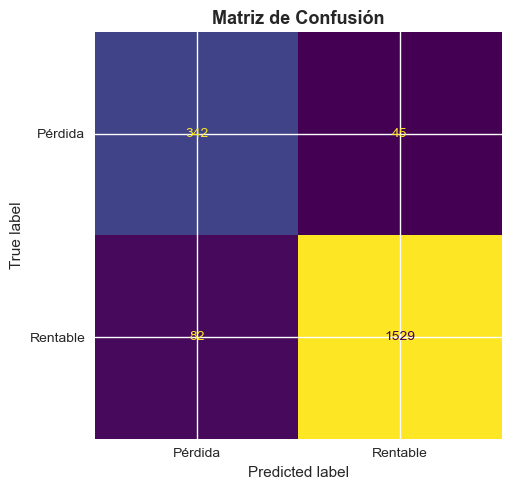

In [7]:
# =============================================
# CELDA 6: Evaluar el modelo
# =============================================

y_pred = modelo.predict(X_test)

print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(
    y_test, y_pred,
    target_names=['Pérdida (0)', 'Rentable (1)']
))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Pérdida', 'Rentable'],
    colorbar=False,
    ax=ax
)
ax.set_title('Matriz de Confusión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

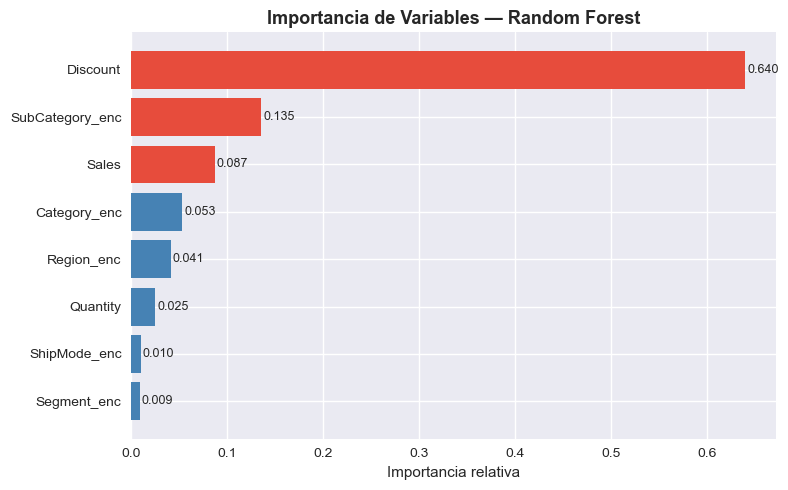

In [8]:
# =============================================
# CELDA 7: Importancia de variables
# =============================================

importancias = pd.DataFrame({
    'Feature'    : features,
    'Importancia': modelo.feature_importances_
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colores = ['#e74c3c' if i >= len(importancias)-3 
           else 'steelblue' for i in range(len(importancias))]

ax.barh(importancias['Feature'], importancias['Importancia'],
        color=colores, edgecolor='none')
ax.set_title('Importancia de Variables — Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa')

# Etiquetas con valores
for i, (val, name) in enumerate(zip(importancias['Importancia'],
                                     importancias['Feature'])):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()